# Structural Networks — Weighted by Number of Synapses

Two weighted directed graphs:
1. **Full network** — all 906 coregistered, proofread neurons
2. **Session 9.3 V1 network** — 93 V1 neurons from session 9, scan 3 (the session with the most V1 neurons in our matched set; all 99 neurons in that session are L4, 93 are in V1)

**Weight = number of synapses (count of synaptic contacts between each pre→post pair).** Counterpart of `KevinStructural.ipynb` which uses cleft size in voxels; this version simply counts how many distinct synapses link each ordered pair. A pair with 5 contacts has weight 5.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx
import pickle
import os
from pathlib import Path

import microns_datacleaner as mic
import microns_datacleaner.filters as fl

---
## Part 1 — Load and Filter Neurons

In [2]:
# Use the root data/ folder so we share raw files with the original notebooks.
cleaner = mic.MicronsDataCleaner(datadir="data", version=1718, download_policy='minimum')
cleaner.tables['celltype'] = 'aibs_metamodel_celltypes_v661'
units, _ = cleaner.process_nucleus_data(functional_data='best_only')

proofread = fl.filter_neurons(units, proofread='ax_clean')
matched   = fl.filter_neurons(proofread, tuning='matched').reset_index(drop=True)

print(f"Full working set: {len(matched)} neurons")

Transform positions:   0%|          | 0/94014 [00:00<?, ?it/s]

Transform positions:   7%|▋         | 6850/94014 [00:00<00:01, 66285.19it/s]

Transform positions:  14%|█▍        | 13479/94014 [00:00<00:01, 61776.73it/s]

Transform positions:  21%|██        | 19797/94014 [00:00<00:01, 60919.25it/s]

Transform positions:  29%|██▊       | 26920/94014 [00:00<00:01, 61740.70it/s]

...

Transform positions:  83%|████████▎ | 77709/94014 [00:01<00:00, 57159.78it/s]

Transform positions:  90%|████████▉ | 84309/94014 [00:01<00:00, 59667.70it/s]

Transform positions:  96%|█████████▋| 90593/94014 [00:01<00:00, 60514.75it/s]

Transform positions: 100%|██████████| 94014/94014 [00:01<00:00, 59871.37it/s]

Full working set: 906 neurons


In [3]:
# Session 9.3 V1 only: session=9, scan_idx=3, brain_area='V1'
sess93_v1 = matched[
    (matched['session']    == 9) &
    (matched['scan_idx']   == 3) &
    (matched['brain_area'] == 'V1')
].reset_index(drop=True)

print(f"Session 9.3 V1 neurons: {len(sess93_v1)}")
print(f"Layer breakdown:     {sess93_v1['layer'].value_counts().to_dict()}")
print(f"Cell type breakdown: {sess93_v1['cell_type'].value_counts().to_dict()}")

Session 9.3 V1 neurons: 93
Layer breakdown:     {'L4': 93}
Cell type breakdown: {'4P': 93}


---
## Part 2 — Load Synapses and Aggregate to Connection Counts

The raw synapse table has one row per synaptic contact (pre → post). Multiple contacts can exist between the same ordered pair. To use **number of synapses** as the edge weight, we group by `(pre_pt_root_id, post_pt_root_id)` and count.

We build two count tables:
- **`syn_counts`** — all (pre, post) pairs among the 906 neurons (autapses removed)
- **`syn_counts_93`** — only pairs where BOTH pre and post are in our 93-neuron V1 set

In [4]:
# Reuse synapses_matched.csv from root data/. The original KevinStructural.ipynb
# builds this from connection_table_*.csv chunks; we read it directly.
raw_synapses_path = Path('data/1718/raw/synapses_matched.csv')

if not raw_synapses_path.exists():
    # Build it from the chunks if needed.
    synapse_dir = Path('data/1718/raw/synapses')
    connection_files = sorted(
        synapse_dir.glob('connections_table_*.csv'),
        key=lambda p: int(p.stem.rsplit('_', 1)[1]),
    )
    if not connection_files:
        raise FileNotFoundError(f'No connection tables found in {synapse_dir}')
    pd.concat((pd.read_csv(p) for p in connection_files), ignore_index=True).to_csv(
        raw_synapses_path, index=False
    )

synapses = pd.read_csv(raw_synapses_path)
synapses = synapses[synapses['pre_pt_root_id'] != synapses['post_pt_root_id']].reset_index(drop=True)

# 18-digit IDs are stored as float64 in CSVs — cast to int64 to match graph node keys.
synapses['pre_pt_root_id']  = synapses['pre_pt_root_id'].astype('int64')
synapses['post_pt_root_id'] = synapses['post_pt_root_id'].astype('int64')
matched['pt_root_id']       = matched['pt_root_id'].astype('int64')
sess93_v1 = matched[
    (matched['session']    == 9) &
    (matched['scan_idx']   == 3) &
    (matched['brain_area'] == 'V1')
].reset_index(drop=True)
sess93_v1['pt_root_id'] = sess93_v1['pt_root_id'].astype('int64')

# Aggregate to per-pair synapse counts (the new edge weight).
syn_counts = (
    synapses
    .groupby(['pre_pt_root_id', 'post_pt_root_id'])
    .size()
    .reset_index(name='n_synapses')
)

print(f"Raw synapse rows:           {len(synapses):,}")
print(f"Unique (pre, post) pairs:   {len(syn_counts):,}")
print(f"Synapses per pair — mean:   {syn_counts['n_synapses'].mean():.2f}")
print(f"Synapses per pair — max:    {syn_counts['n_synapses'].max()}")
print(f"Pairs with ≥2 synapses:      {(syn_counts['n_synapses']>=2).sum():,}")
print()

ids_93 = set(sess93_v1['pt_root_id'].astype('int64').tolist())
syn_counts_93 = syn_counts[
    syn_counts['pre_pt_root_id'].isin(ids_93) &
    syn_counts['post_pt_root_id'].isin(ids_93)
].reset_index(drop=True)

print(f"Session 9.3 V1 (pre, post) pairs: {len(syn_counts_93):,}")
if len(syn_counts_93) > 0:
    print(f"Synapses per pair — mean:        {syn_counts_93['n_synapses'].mean():.2f}")
    print(f"Synapses per pair — max:         {syn_counts_93['n_synapses'].max()}")

Raw synapse rows:           182,352
Unique (pre, post) pairs:   182,352
Synapses per pair — mean:   1.00
Synapses per pair — max:    1
Pairs with ≥2 synapses:      0

Session 9.3 V1 (pre, post) pairs: 229
Synapses per pair — mean:        1.00
Synapses per pair — max:         1


---
## Part 3 — Build Weighted Directed Graphs

`nx.DiGraph` where:
- **Nodes** carry attributes: `layer`, `cell_type`, `brain_area`, `pref_ori`, `gOSI`, spatial position
- **Edges** carry `weight` = number of synapses between pre and post

**Out-strength** = sum of synapse counts on outgoing edges = total outgoing synapses.
**In-strength**  = sum of synapse counts on incoming edges = total incoming synapses.

In [5]:
def build_count_digraph(neurons_df, syn_count_df):
    G = nx.DiGraph()

    node_ids    = neurons_df['pt_root_id'].astype('int64').tolist()
    layers      = neurons_df['layer'].tolist()
    cell_types  = neurons_df['cell_type'].tolist()
    brain_areas = neurons_df['brain_area'].tolist()
    pref_oris   = neurons_df['pref_ori'].tolist()
    gOSIs       = neurons_df['gOSI'].tolist()
    xs          = neurons_df['pt_position_x'].tolist()
    ys          = neurons_df['pt_position_y'].tolist()
    zs          = neurons_df['pt_position_z'].tolist()

    for i, nid in enumerate(node_ids):
        G.add_node(nid, layer=layers[i], cell_type=cell_types[i],
                   brain_area=brain_areas[i], pref_ori=pref_oris[i],
                   gOSI=gOSIs[i], x=xs[i], y=ys[i], z=zs[i])

    node_set = set(G.nodes())
    pre_ids  = syn_count_df['pre_pt_root_id'].astype('int64').tolist()
    post_ids = syn_count_df['post_pt_root_id'].astype('int64').tolist()
    counts   = syn_count_df['n_synapses'].tolist()

    edges_added = 0
    for pre, post, c in zip(pre_ids, post_ids, counts):
        if pre in node_set and post in node_set:
            G.add_edge(pre, post, weight=int(c))
            edges_added += 1

    print(f"  Nodes: {G.number_of_nodes()}, edges added: {edges_added}")
    return G

print('Building 906-neuron network...')
G_906 = build_count_digraph(matched, syn_counts)

if len(sess93_v1) == 0:
    raise ValueError('sess93_v1 is empty. Re-run Part 1 cells before building G_93.')

print('Building 93-neuron network...')
G_93  = build_count_digraph(sess93_v1, syn_counts_93)
if G_93.number_of_nodes() == 0:
    raise ValueError('G_93 has 0 nodes. Re-run the sess93_v1 filtering cell first.')

print()
print(f"Full 906-neuron network:     {G_906.number_of_nodes()} nodes, {G_906.number_of_edges():,} edges, density={nx.density(G_906):.4f}")
print(f"Session 9.3 V1 network (93): {G_93.number_of_nodes()}  nodes, {G_93.number_of_edges():,} edges,  density={nx.density(G_93):.4f}")

Building 906-neuron network...


  Nodes: 906, edges added: 11822
Building 93-neuron network...
  Nodes: 93, edges added: 229

Full 906-neuron network:     906 nodes, 11,822 edges, density=0.0144
Session 9.3 V1 network (93): 93  nodes, 229 edges,  density=0.0268


---
## Part 4 — Degree and Strength Statistics

**Degree** = number of distinct partners (unweighted).
**Strength** = sum of synapse counts across all connections (weighted) = total number of synapses involving the neuron.

Where the size-based version asks *how big are the synapses?*, here strength asks *how many synapses?*. A high-degree neuron with strength close to its degree forms mostly single-contact connections; high strength relative to degree signals multi-contact partnerships.

In [6]:
def compute_stats(G, label):
    if G.number_of_nodes() == 0:
        raise ValueError(f'{label} has 0 nodes. Re-run the graph-building cell first.')
    out_deg = np.array([d for _, d in G.out_degree()])
    in_deg  = np.array([d for _, d in G.in_degree()])
    out_str = np.array([d for _, d in G.out_degree(weight='weight')])
    in_str  = np.array([d for _, d in G.in_degree(weight='weight')])
    return out_deg, in_deg, out_str, in_str

out_deg_906, in_deg_906, out_str_906, in_str_906 = compute_stats(G_906, 'G_906')
out_deg_93,  in_deg_93,  out_str_93,  in_str_93  = compute_stats(G_93, 'G_93')

def print_stats(label, out_deg, in_deg, out_str, in_str):
    print(f"\n{'='*56}")
    print(f" {label}")
    print(f"{'='*56}")
    print(f"  {'Metric':<35} {'Out':>9} {'In':>9}")
    print(f"  {'-'*53}")
    print(f"  {'Mean degree (partners)':<35} {out_deg.mean():>9.2f} {in_deg.mean():>9.2f}")
    print(f"  {'Max degree':<35} {out_deg.max():>9} {in_deg.max():>9}")
    print(f"  {'Neurons with degree 0':<35} {(out_deg==0).sum():>9} {(in_deg==0).sum():>9}")
    print(f"  {'Mean strength (# synapses)':<35} {out_str.mean():>9.2f} {in_str.mean():>9.2f}")
    print(f"  {'Max strength (# synapses)':<35} {out_str.max():>9} {in_str.max():>9}")

print_stats('Full 906-neuron Network',     out_deg_906, in_deg_906, out_str_906, in_str_906)
print_stats('Session 9.3 V1 Network (93)', out_deg_93,  in_deg_93,  out_str_93,  in_str_93)


 Full 906-neuron Network
  Metric                                    Out        In
  -----------------------------------------------------
  Mean degree (partners)                  13.05     13.05
  Max degree                                 69        98
  Neurons with degree 0                      34         6
  Mean strength (# synapses)              13.05     13.05
  Max strength (# synapses)                  69        98

 Session 9.3 V1 Network (93)
  Metric                                    Out        In
  -----------------------------------------------------
  Mean degree (partners)                   2.46      2.46
  Max degree                                  8        11
  Neurons with degree 0                      16        20
  Mean strength (# synapses)               2.46      2.46
  Max strength (# synapses)                   8        11


---
## Part 5 — Strength and Degree Distributions

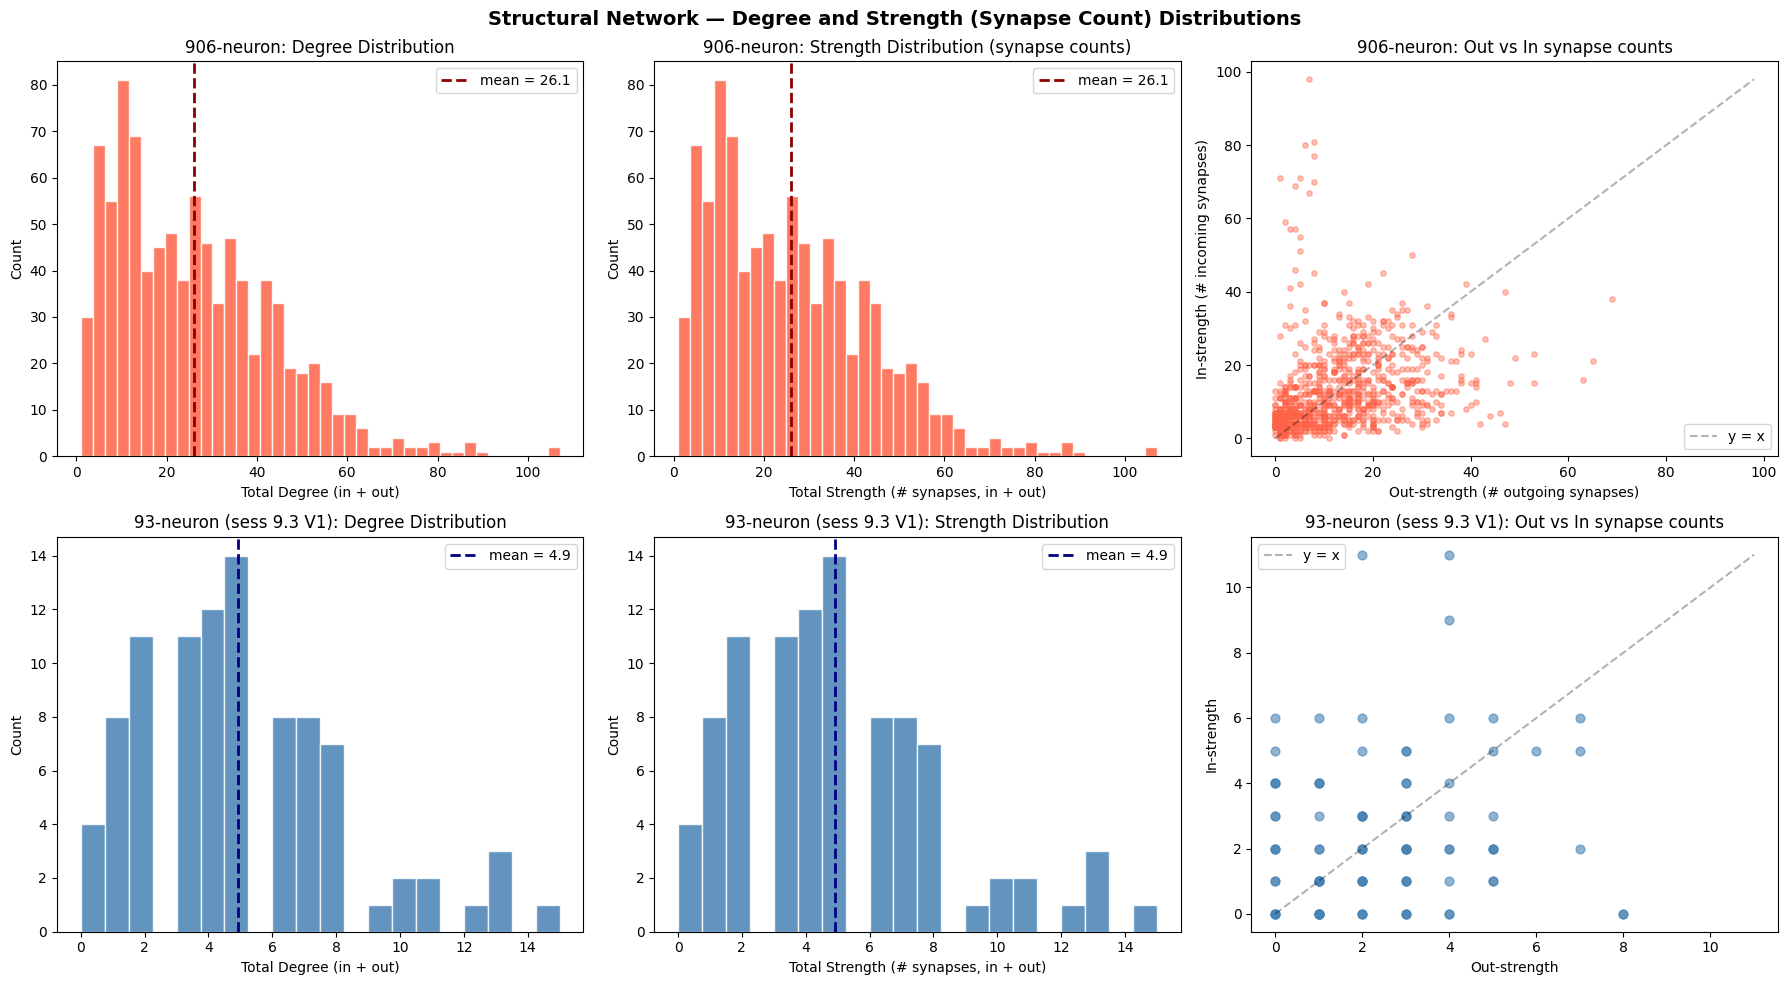

In [7]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# Row 1: 906-neuron
total_deg_906 = out_deg_906 + in_deg_906
axes[0,0].hist(total_deg_906, bins=40, color='tomato', edgecolor='white', alpha=0.85)
axes[0,0].axvline(total_deg_906.mean(), color='darkred', lw=2, linestyle='--',
                  label=f'mean = {total_deg_906.mean():.1f}')
axes[0,0].set_xlabel('Total Degree (in + out)')
axes[0,0].set_ylabel('Count')
axes[0,0].set_title('906-neuron: Degree Distribution')
axes[0,0].legend()

total_str_906 = out_str_906 + in_str_906
axes[0,1].hist(total_str_906, bins=40, color='tomato', edgecolor='white', alpha=0.85)
axes[0,1].axvline(total_str_906.mean(), color='darkred', lw=2, linestyle='--',
                  label=f'mean = {total_str_906.mean():.1f}')
axes[0,1].set_xlabel('Total Strength (# synapses, in + out)')
axes[0,1].set_ylabel('Count')
axes[0,1].set_title('906-neuron: Strength Distribution (synapse counts)')
axes[0,1].legend()

m = max(out_str_906.max(), in_str_906.max())
axes[0,2].scatter(out_str_906, in_str_906, alpha=0.4, s=15, color='tomato')
axes[0,2].plot([0, m], [0, m], 'k--', alpha=0.3, label='y = x')
axes[0,2].set_xlabel('Out-strength (# outgoing synapses)')
axes[0,2].set_ylabel('In-strength (# incoming synapses)')
axes[0,2].set_title('906-neuron: Out vs In synapse counts')
axes[0,2].legend()

# Row 2: 93-neuron
total_deg_93 = out_deg_93 + in_deg_93
axes[1,0].hist(total_deg_93, bins=20, color='steelblue', edgecolor='white', alpha=0.85)
axes[1,0].axvline(total_deg_93.mean(), color='navy', lw=2, linestyle='--',
                  label=f'mean = {total_deg_93.mean():.1f}')
axes[1,0].set_xlabel('Total Degree (in + out)')
axes[1,0].set_ylabel('Count')
axes[1,0].set_title('93-neuron (sess 9.3 V1): Degree Distribution')
axes[1,0].legend()

total_str_93 = out_str_93 + in_str_93
axes[1,1].hist(total_str_93, bins=20, color='steelblue', edgecolor='white', alpha=0.85)
axes[1,1].axvline(total_str_93.mean(), color='navy', lw=2, linestyle='--',
                  label=f'mean = {total_str_93.mean():.1f}')
axes[1,1].set_xlabel('Total Strength (# synapses, in + out)')
axes[1,1].set_ylabel('Count')
axes[1,1].set_title('93-neuron (sess 9.3 V1): Strength Distribution')
axes[1,1].legend()

if out_str_93.max() > 0:
    m2 = max(out_str_93.max(), in_str_93.max())
    axes[1,2].scatter(out_str_93, in_str_93, alpha=0.6, s=40, color='steelblue')
    axes[1,2].plot([0, m2], [0, m2], 'k--', alpha=0.3, label='y = x')
    axes[1,2].legend()
axes[1,2].set_xlabel('Out-strength')
axes[1,2].set_ylabel('In-strength')
axes[1,2].set_title('93-neuron (sess 9.3 V1): Out vs In synapse counts')

plt.suptitle('Structural Network — Degree and Strength (Synapse Count) Distributions',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

---
## Part 6 — Per-Pair Synapse Count Distribution

Distribution of edge weights = how many synapses connect each (pre, post) pair. Most pairs have a single contact; a long right tail indicates the multi-contact partnerships that dominate total synapse count.

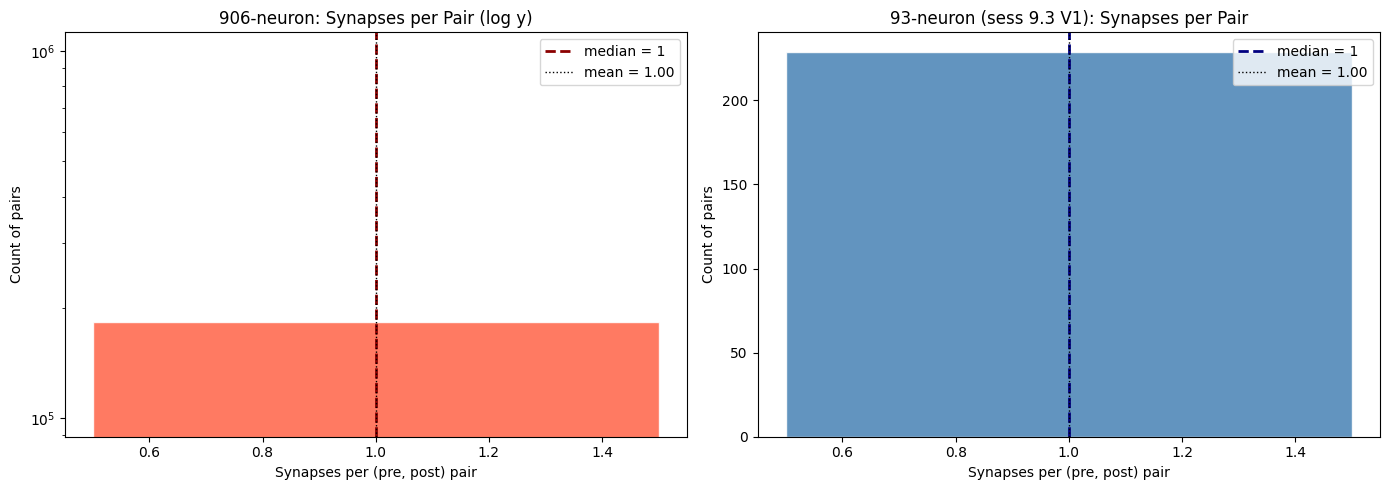

906-network — median: 1, mean: 1.00, max: 1, total synapses: 182,352
93-network  — median: 1, mean: 1.00, max: 1, total synapses: 229


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

counts_906 = syn_counts['n_synapses'].values
max_count_906 = counts_906.max()
bins_906 = np.arange(0.5, max_count_906 + 1.5, 1)
axes[0].hist(counts_906, bins=bins_906, color='tomato', edgecolor='white', alpha=0.85)
axes[0].axvline(np.median(counts_906), color='darkred', lw=2, linestyle='--',
                label=f'median = {np.median(counts_906):.0f}')
axes[0].axvline(counts_906.mean(), color='black', lw=1, linestyle=':',
                label=f'mean = {counts_906.mean():.2f}')
axes[0].set_xlabel('Synapses per (pre, post) pair')
axes[0].set_ylabel('Count of pairs')
axes[0].set_yscale('log')
axes[0].set_title('906-neuron: Synapses per Pair (log y)')
axes[0].legend()

counts_93 = syn_counts_93['n_synapses'].values
if len(counts_93) > 0:
    bins_93 = np.arange(0.5, counts_93.max() + 1.5, 1)
    axes[1].hist(counts_93, bins=bins_93, color='steelblue', edgecolor='white', alpha=0.85)
    axes[1].axvline(np.median(counts_93), color='navy', lw=2, linestyle='--',
                    label=f'median = {np.median(counts_93):.0f}')
    axes[1].axvline(counts_93.mean(), color='black', lw=1, linestyle=':',
                    label=f'mean = {counts_93.mean():.2f}')
    axes[1].legend()
axes[1].set_xlabel('Synapses per (pre, post) pair')
axes[1].set_ylabel('Count of pairs')
axes[1].set_title('93-neuron (sess 9.3 V1): Synapses per Pair')

plt.tight_layout()
plt.show()

print(f'906-network — median: {np.median(counts_906):.0f}, mean: {counts_906.mean():.2f}, max: {counts_906.max()}, total synapses: {counts_906.sum():,}')
if len(counts_93) > 0:
    print(f'93-network  — median: {np.median(counts_93):.0f}, mean: {counts_93.mean():.2f}, max: {counts_93.max()}, total synapses: {counts_93.sum():,}')

---
## Part 7 — Network Visualizations

**93-neuron:** Spring layout, edge thickness and opacity proportional to synapse count (multi-contact pairs are visibly thicker).
**906-neuron:** Actual x/z tissue coordinates. Node size ∝ total synapse count. Only multi-synapse edges drawn to reduce clutter.

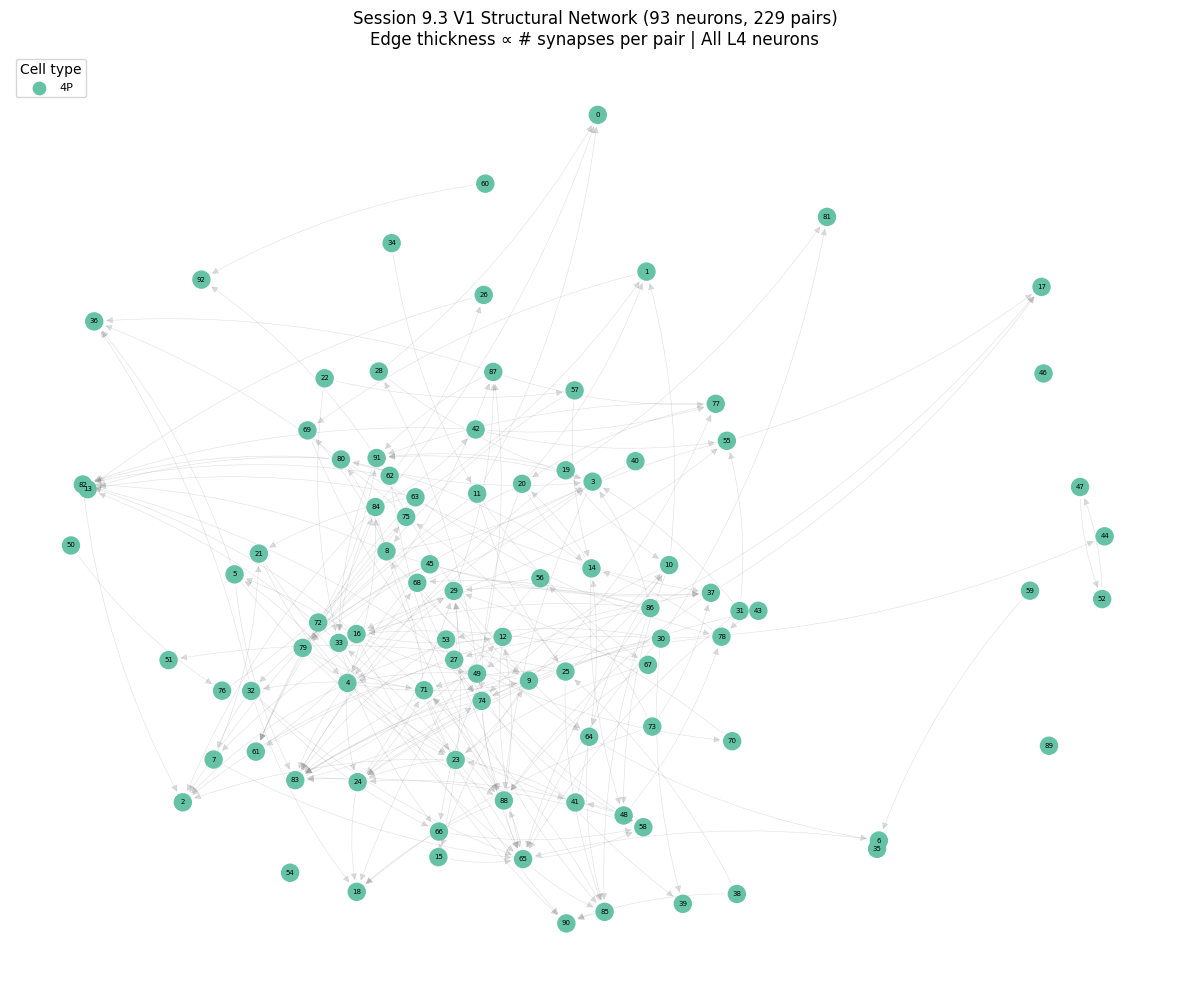

In [9]:
# 93-neuron: spring layout
fig, ax = plt.subplots(figsize=(12, 10))

np.random.seed(42)
pos_93 = nx.spring_layout(G_93, weight='weight', seed=42, k=0.5)

cell_types_93 = [G_93.nodes[n]['cell_type'] for n in G_93.nodes()]
unique_types  = sorted(set(cell_types_93))
cmap_nodes    = plt.cm.Set2(np.linspace(0, 1, max(len(unique_types), 1)))
color_map     = {ct: cmap_nodes[i] for i, ct in enumerate(unique_types)}
node_colors   = [color_map[ct] for ct in cell_types_93]

edge_w_93 = np.array([G_93[u][v]['weight'] for u, v in G_93.edges()])
if len(edge_w_93) > 0:
    norm_w = (edge_w_93 - edge_w_93.min()) / (edge_w_93.max() - edge_w_93.min() + 1e-9)
    widths = 0.4 + 3.5 * norm_w
    alphas = 0.25 + 0.6 * norm_w
    for (u, v), w, a in zip(G_93.edges(), widths, alphas):
        nx.draw_networkx_edges(G_93, pos_93, edgelist=[(u, v)], width=float(w),
                               alpha=float(a), edge_color='gray', arrows=True,
                               arrowsize=10, connectionstyle='arc3,rad=0.1', ax=ax)

nx.draw_networkx_nodes(G_93, pos_93, node_color=node_colors, node_size=150, ax=ax)
nx.draw_networkx_labels(G_93, pos_93,
                        labels={n: str(i) for i, n in enumerate(G_93.nodes())},
                        font_size=5, ax=ax)
for ct, c in color_map.items():
    ax.scatter([], [], c=[c], s=80, label=ct)
ax.legend(title='Cell type', loc='upper left', fontsize=8)
ax.set_title(
    f'Session 9.3 V1 Structural Network ({G_93.number_of_nodes()} neurons, {G_93.number_of_edges()} pairs)\n'
    f'Edge thickness ∝ # synapses per pair | All L4 neurons',
    fontsize=12
)
ax.axis('off')
plt.tight_layout()
plt.show()

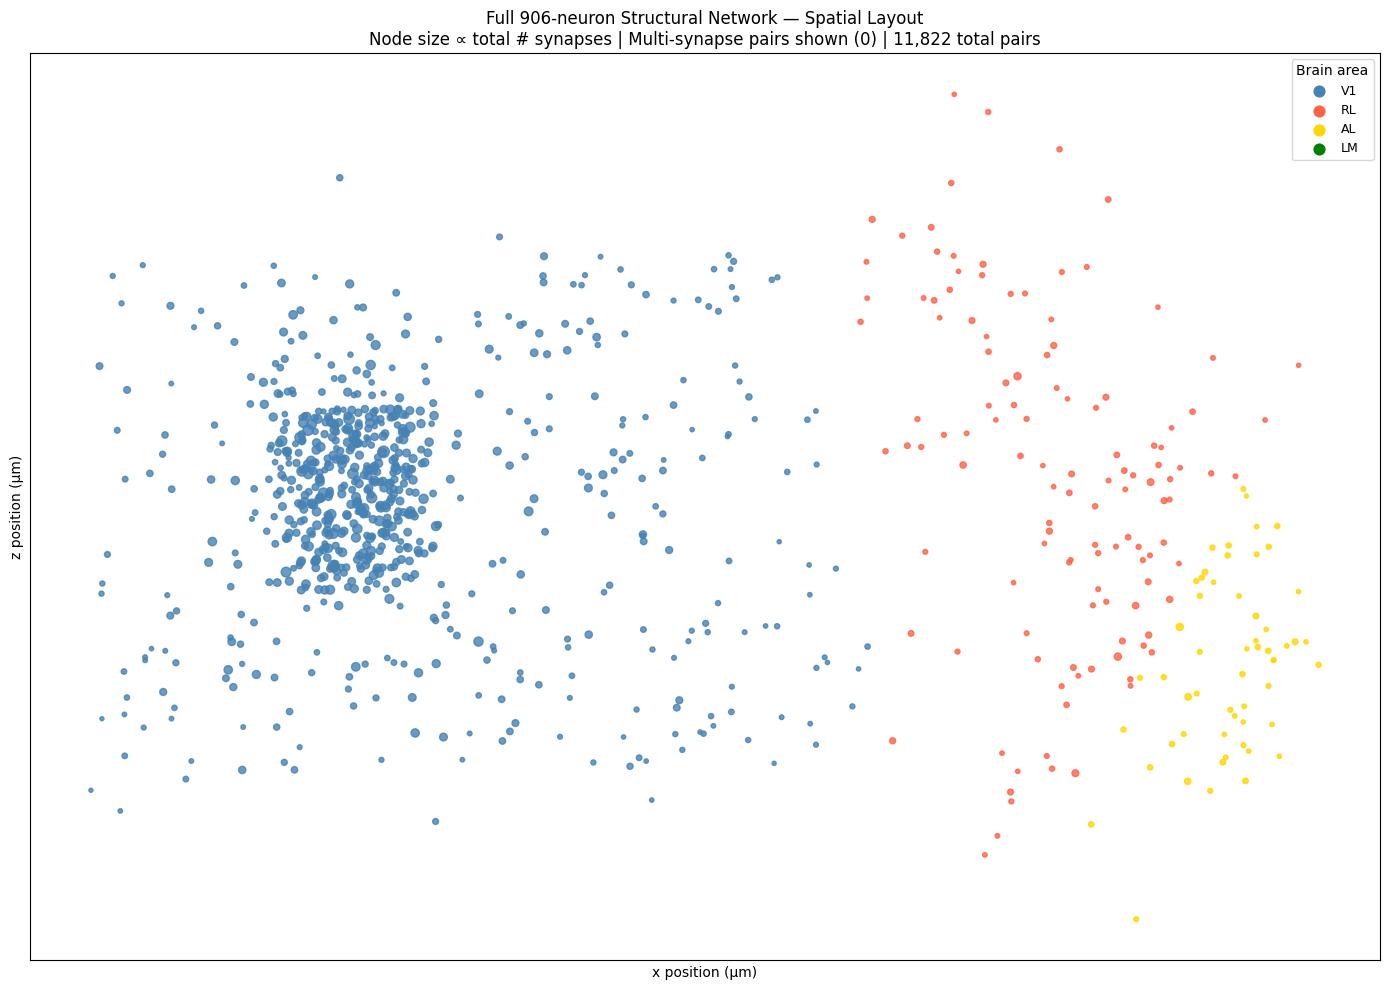

In [10]:
# 906-neuron: spatial layout
fig, ax = plt.subplots(figsize=(14, 10))

pos_906       = {n: (G_906.nodes[n]['x'], G_906.nodes[n]['z']) for n in G_906.nodes()}
area_colors   = {'V1': 'steelblue', 'RL': 'tomato', 'AL': 'gold', 'LM': 'green'}
node_cols_906 = [area_colors.get(G_906.nodes[n]['brain_area'], 'gray') for n in G_906.nodes()]
total_str_all = np.array([G_906.degree(n, weight='weight') for n in G_906.nodes()])
node_sz       = 8 + 60 * (total_str_all / total_str_all.max())

# Show pairs with at least 2 synapses (the multi-contact backbone).
all_w_906   = np.array([G_906[u][v]['weight'] for u, v in G_906.edges()])
heavy_edges = [(u, v) for u, v in G_906.edges() if G_906[u][v]['weight'] >= 2]

nx.draw_networkx_edges(G_906, pos_906, edgelist=heavy_edges,
                       alpha=0.08, width=0.5, edge_color='gray', arrows=False, ax=ax)
nx.draw_networkx_nodes(G_906, pos_906, node_color=node_cols_906,
                       node_size=node_sz, alpha=0.8, ax=ax)

for area, color in area_colors.items():
    ax.scatter([], [], c=color, s=60, label=area)
ax.legend(title='Brain area', loc='upper right', fontsize=9)
ax.set_title(
    f'Full 906-neuron Structural Network — Spatial Layout\n'
    f'Node size ∝ total # synapses | Multi-synapse pairs shown ({len(heavy_edges):,}) | {G_906.number_of_edges():,} total pairs',
    fontsize=12
)
ax.set_xlabel('x position (μm)')
ax.set_ylabel('z position (μm)')
plt.tight_layout()
plt.show()

---
## Part 8 — Summary Table

In [11]:
summary = pd.DataFrame({
    'Metric': [
        'Nodes', 'Edges (pairs)', 'Network density',
        'Mean out-degree', 'Mean in-degree', 'Max out-degree', 'Max in-degree',
        'Mean out-strength (# synapses)', 'Mean in-strength (# synapses)',
        'Max out-strength (# synapses)', 'Max in-strength (# synapses)',
        'Median synapses per pair', 'Max synapses per pair',
        'Total synapses', 'Neurons with zero output', 'Neurons with zero input',
    ],
    'Full 906-neuron': [
        G_906.number_of_nodes(), G_906.number_of_edges(), f"{nx.density(G_906):.4f}",
        f"{out_deg_906.mean():.2f}", f"{in_deg_906.mean():.2f}",
        int(out_deg_906.max()), int(in_deg_906.max()),
        f"{out_str_906.mean():.2f}", f"{in_str_906.mean():.2f}",
        int(out_str_906.max()), int(in_str_906.max()),
        f"{np.median(counts_906):.0f}", int(counts_906.max()),
        int(counts_906.sum()),
        int((out_deg_906 == 0).sum()), int((in_deg_906 == 0).sum()),
    ],
    'Session 9.3 V1 (93 neurons)': [
        G_93.number_of_nodes(), G_93.number_of_edges(), f"{nx.density(G_93):.4f}",
        f"{out_deg_93.mean():.2f}", f"{in_deg_93.mean():.2f}",
        int(out_deg_93.max()), int(in_deg_93.max()),
        f"{out_str_93.mean():.2f}", f"{in_str_93.mean():.2f}",
        int(out_str_93.max()), int(in_str_93.max()),
        f"{np.median(counts_93):.0f}" if len(counts_93) > 0 else 'N/A',
        int(counts_93.max()) if len(counts_93) > 0 else 0,
        int(counts_93.sum()) if len(counts_93) > 0 else 0,
        int((out_deg_93 == 0).sum()), int((in_deg_93 == 0).sum()),
    ]
})

print(summary.to_string(index=False))

                        Metric Full 906-neuron Session 9.3 V1 (93 neurons)
                         Nodes             906                          93
                 Edges (pairs)           11822                         229
               Network density          0.0144                      0.0268
               Mean out-degree           13.05                        2.46
                Mean in-degree           13.05                        2.46
                Max out-degree              69                           8
                 Max in-degree              98                          11
Mean out-strength (# synapses)           13.05                        2.46
 Mean in-strength (# synapses)           13.05                        2.46
 Max out-strength (# synapses)              69                           8
  Max in-strength (# synapses)              98                          11
      Median synapses per pair               1                           1
         Max synapses per

In [12]:
# Save both graphs to data/. Suffix _count distinguishes them from the
# size-based G_906.pkl / G_93.pkl produced by KevinStructural.ipynb.
os.makedirs('data', exist_ok=True)

with open('data/G_906_count.pkl', 'wb') as f:
    pickle.dump(G_906, f)
with open('data/G_93_count.pkl', 'wb') as f:
    pickle.dump(G_93, f)

print('Saved: data/G_906_count.pkl  and  data/G_93_count.pkl')
print("Reload with:  G = pickle.load(open('data/G_906_count.pkl', 'rb'))")

Saved: data/G_906_count.pkl  and  data/G_93_count.pkl
Reload with:  G = pickle.load(open('data/G_906_count.pkl', 'rb'))
